<a href="https://colab.research.google.com/github/Akash-Behera-123/DL-BasicProject/blob/main/DL_5_FaceMaskDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_53754b8e2afbaf3fb8a8ef9f98a5ea3d'

In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:00<00:00, 214MB/s]



In [ ]:
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r')as zip:
  zip.extractall()
  print('the dataset is extracted')

the dataset is extracted


In [ ]:
!ls

data  face-mask-dataset.zip  sample_data


**Importing the Dependencies**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image  as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [ ]:
with_mask_files=os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_1473.jpg', 'with_mask_806.jpg', 'with_mask_1839.jpg', 'with_mask_2528.jpg', 'with_mask_164.jpg']
['with_mask_1329.jpg', 'with_mask_547.jpg', 'with_mask_3141.jpg', 'with_mask_2912.jpg', 'with_mask_828.jpg']


In [ ]:
without_mask_files=os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_3235.jpg', 'without_mask_2424.jpg', 'without_mask_2416.jpg', 'without_mask_3161.jpg', 'without_mask_3487.jpg']
['without_mask_389.jpg', 'without_mask_3687.jpg', 'without_mask_1674.jpg', 'without_mask_1619.jpg', 'without_mask_2828.jpg']


In [ ]:
print('Number of with mask images',len(with_mask_files))
print('Number of without mask images',len(without_mask_files))

Number of with mask images 3725
Number of without mask images 3828


Creating Lables for the two class of image

with mask-->1

without mask->0

In [ ]:
#creating the labels

with_mask_labels=[1]*3725

without_mask_labels=[0]*3828

In [ ]:
print(with_mask_labels[0:5])
print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [ ]:
labels=with_mask_labels+without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


**Displaying the images**

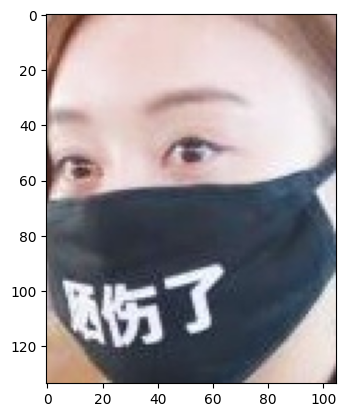

In [ ]:
#displaying with mask image
img=mpimg.imread('/content/data/with_mask/with_mask_1473.jpg')
imgplot=plt.imshow(img)
plt.show()

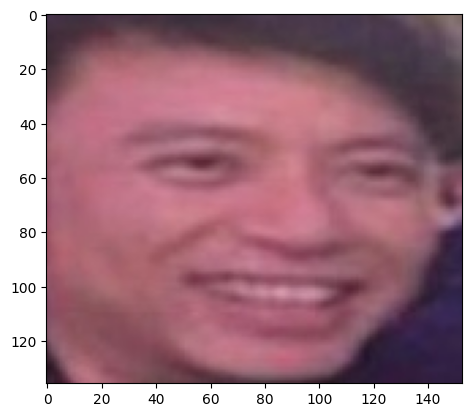

In [ ]:
#displaying without mask image
img=mpimg.imread('/content/data/without_mask/without_mask_389.jpg')
imgplot=plt.imshow(img)
plt.show()

#**Image Processing**

1.Resize the images


2.Convert the images to numpy arrays

In [ ]:
#convert images to numpy arrays

with_mask_path='/content/data/with_mask'

data=[]

for img_file in with_mask_files:
   image= Image.open(os.path.join(with_mask_path,img_file))
   image = image.resize((128,128))
   image= image.convert('RGB')
   image= np.array(image)
   data.append(image)


without_mask_path='/content/data/without_mask'


for img_file in without_mask_files:
   image= Image.open(os.path.join(without_mask_path,img_file))
   image = image.resize((128,128))
   image= image.convert('RGB')
   image= np.array(image)
   data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
type(data)

list

In [ ]:
len(data)

7553

array([[[192, 163, 155],
        [178, 149, 139],
        [158, 126, 115],
        ...,
        [175, 141, 137],
        [166, 133, 131],
        [155, 125, 123]],

       [[186, 156, 146],
        [176, 145, 134],
        [154, 120, 106],
        ...,
        [178, 145, 139],
        [173, 141, 136],
        [170, 139, 137]],

       [[183, 149, 136],
        [168, 133, 119],
        [151, 114,  98],
        ...,
        [173, 140, 134],
        [178, 146, 140],
        [176, 145, 143]],

       ...,

       [[204, 160, 133],
        [202, 158, 130],
        [199, 155, 126],
        ...,
        [164, 150, 150],
        [104,  90,  91],
        [ 64,  48,  52]],

       [[203, 158, 129],
        [200, 157, 126],
        [197, 154, 122],
        ...,
        [129, 115, 115],
        [ 72,  58,  59],
        [ 44,  33,  35]],

       [[200, 155, 124],
        [197, 152, 121],
        [194, 150, 117],
        ...,
        [ 82,  67,  67],
        [ 64,  51,  51],
        [ 52,  40,  42]]], dtype=uint8)
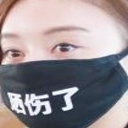

In [ ]:
data[0]

array([[[ 49,  25,  25],
        [ 50,  26,  26],
        [ 48,  24,  22],
        ...,
        [ 56,  42,  41],
        [ 57,  43,  42],
        [ 58,  43,  40]],

       [[ 48,  22,  23],
        [ 50,  24,  23],
        [ 50,  24,  23],
        ...,
        [ 56,  42,  41],
        [ 56,  42,  41],
        [ 58,  43,  40]],

       [[ 49,  21,  20],
        [ 53,  25,  22],
        [ 55,  27,  24],
        ...,
        [ 53,  42,  38],
        [ 54,  43,  39],
        [ 56,  42,  39]],

       ...,

       [[219, 104,  77],
        [217, 102,  75],
        [217, 103,  77],
        ...,
        [ 73,  59,  58],
        [ 72,  58,  57],
        [ 72,  56,  56]],

       [[222, 104,  76],
        [220, 105,  78],
        [221, 106,  79],
        ...,
        [ 75,  59,  59],
        [ 73,  57,  57],
        [ 75,  57,  57]],

       [[223, 105,  77],
        [223, 105,  77],
        [222, 107,  80],
        ...,
        [ 75,  59,  59],
        [ 74,  58,  58],
        [ 75,  57,  57]]], dtype=uint8)
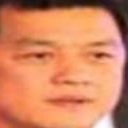

In [ ]:
data[4567]

In [ ]:
#converting image list and label list to numpy arrays

X =np.array(data)
Y =np.array(labels)

In [ ]:
type(X)

numpy.ndarray

In [ ]:
type(Y)

numpy.ndarray

In [ ]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


Train Test Split


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [ ]:
print(X.shape,x_train.shape,x_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [ ]:
#scaling the data

x_train_scaled = x_train/255


x_test_scaled = x_test/255


array([[[219, 213, 215],
        [219, 213, 215],
        [219, 213, 215],
        ...,
        [224, 218, 220],
        [224, 218, 220],
        [224, 218, 220]],

       [[219, 213, 215],
        [219, 213, 215],
        [219, 213, 215],
        ...,
        [224, 218, 220],
        [224, 218, 220],
        [224, 218, 220]],

       [[219, 213, 215],
        [219, 213, 215],
        [219, 213, 215],
        ...,
        [224, 218, 220],
        [224, 218, 220],
        [224, 218, 220]],

       ...,

       [[  7,   7,   9],
        [  7,   7,   9],
        [  6,   6,   8],
        ...,
        [228, 222, 224],
        [228, 222, 224],
        [228, 222, 224]],

       [[  7,   7,   9],
        [  6,   6,   8],
        [  5,   5,   7],
        ...,
        [228, 222, 224],
        [228, 222, 224],
        [228, 222, 224]],

       [[  6,   6,   8],
        [  6,   6,   8],
        [  5,   5,   7],
        ...,
        [229, 223, 225],
        [229, 223, 225],
        [228, 222, 224]]], dtype=uint8)
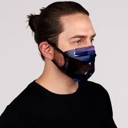

In [ ]:
x_train[0]

In [ ]:
x_train_scaled[0]

array([[[0.85882353, 0.83529412, 0.84313725],
        [0.85882353, 0.83529412, 0.84313725],
        [0.85882353, 0.83529412, 0.84313725],
        ...,
        [0.87843137, 0.85490196, 0.8627451 ],
        [0.87843137, 0.85490196, 0.8627451 ],
        [0.87843137, 0.85490196, 0.8627451 ]],

       [[0.85882353, 0.83529412, 0.84313725],
        [0.85882353, 0.83529412, 0.84313725],
        [0.85882353, 0.83529412, 0.84313725],
        ...,
        [0.87843137, 0.85490196, 0.8627451 ],
        [0.87843137, 0.85490196, 0.8627451 ],
        [0.87843137, 0.85490196, 0.8627451 ]],

       [[0.85882353, 0.83529412, 0.84313725],
        [0.85882353, 0.83529412, 0.84313725],
        [0.85882353, 0.83529412, 0.84313725],
        ...,
        [0.87843137, 0.85490196, 0.8627451 ],
        [0.87843137, 0.85490196, 0.8627451 ],
        [0.87843137, 0.85490196, 0.8627451 ]],

       ...,

       [[0.02745098, 0.02745098, 0.03529412],
        [0.02745098, 0.02745098, 0.03529412],
        [0.02352941, 0

#Building a Convolutional Neural Network (CNN)

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
num_of_classes =2

model = keras.Sequential()


model.add(keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(128,128,3)))

model.add(keras.layers.MaxPool2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu'))

model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128,activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes,activation='sigmoid'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Compiling the neural Network

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [ ]:
#training the neural network
history = model.fit(x_train_scaled,y_train,validation_split=0.1,epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - acc: 0.8238 - loss: 0.4191 - val_acc: 0.8777 - val_loss: 0.2890
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - acc: 0.8994 - loss: 0.2561 - val_acc: 0.8942 - val_loss: 0.2483
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - acc: 0.9198 - loss: 0.2064 - val_acc: 0.9174 - val_loss: 0.2435
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - acc: 0.9336 - loss: 0.1696 - val_acc: 0.9207 - val_loss: 0.2415
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - acc: 0.9463 - loss: 0.1426 - val_acc: 0.9107 - val_loss: 0.2640


**Model Evaluation**

In [ ]:
loss,accuracy = model = model.evaluate(x_test_scaled,y_test)
print('Test Accuracy =',accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9212 - loss: 0.2106
Test Accuracy = 0.921244204044342


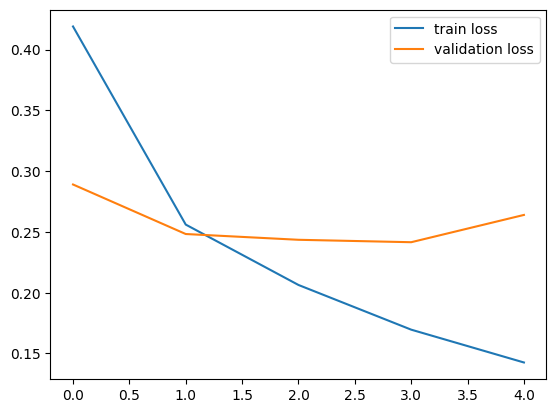

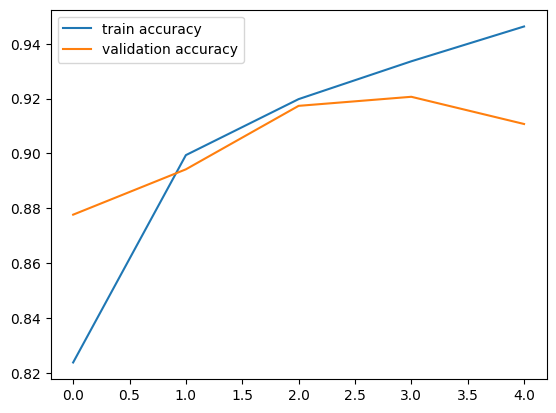

In [ ]:
h= history

#plot the loss value
plt.plot(h.history['loss'],label='train loss')
plt.plot(h.history['val_loss'],label='validation loss')

plt.legend()
plt.show()


#plot the loss value
plt.plot(h.history['acc'],label='train accuracy')
plt.plot(h.history['val_acc'],label='validation accuracy')

plt.legend()
plt.show()

#}Predictive System

In [ ]:
input_image_path= input('path of the image to be predicted: ')

input_image =cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized =cv2.resize(input_image,(128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled,[1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label==1:
    print('the person in the image is wearing a mask')

else:
    print('peroson is not wearing the mask')